# ch296 — Optimization Methods

*(Extends gradient descent from ch213; connects to neural network training from ch295)*

## 1. Why SGD Is Not Enough

Vanilla gradient descent works for convex problems with a well-conditioned Hessian. Neural networks are non-convex, high-dimensional, and have vastly different curvature in different directions. Practical training requires:

- **Momentum**: accumulate gradients across steps to escape local curvature
- **Adaptive learning rates**: scale updates by historical gradient magnitude per parameter
- **Regularization**: prevent overfitting by penalizing large weights
- **Learning rate schedules**: reduce LR as training progresses

---

## 2. Optimizer Implementations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---- Optimizer base ----
class Optimizer:
    def step(self, params, grads): raise NotImplementedError

class SGD(Optimizer):
    def __init__(self, lr=0.01): self.lr = lr
    def step(self, params, grads):
        return [p - self.lr * g for p, g in zip(params, grads)]

class SGDMomentum(Optimizer):
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr; self.momentum = momentum; self.v = None
    def step(self, params, grads):
        if self.v is None:
            self.v = [np.zeros_like(p) for p in params]
        new_params = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.v[i] = self.momentum * self.v[i] - self.lr * g
            new_params.append(p + self.v[i])
        return new_params

class RMSProp(Optimizer):
    def __init__(self, lr=0.001, beta=0.9, eps=1e-8):
        self.lr = lr; self.beta = beta; self.eps = eps; self.s = None
    def step(self, params, grads):
        if self.s is None:
            self.s = [np.zeros_like(p) for p in params]
        new_params = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.s[i] = self.beta * self.s[i] + (1 - self.beta) * g**2
            new_params.append(p - self.lr * g / (np.sqrt(self.s[i]) + self.eps))
        return new_params

class Adam(Optimizer):
    """
    Adaptive Moment Estimation (Kingma & Ba 2015).
    Combines momentum (first moment) with RMSProp (second moment).
    Bias-corrected estimates in early steps.
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2
        self.eps = eps; self.m = None; self.v = None; self.t = 0

    def step(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]
            self.v = [np.zeros_like(p) for p in params]
        self.t += 1
        new_params = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2
            # Bias correction
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)
            new_params.append(p - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))
        return new_params

print('Optimizers defined: SGD, SGDMomentum, RMSProp, Adam')

Optimizers defined: SGD, SGDMomentum, RMSProp, Adam


## 3. Comparison on a Non-Convex Loss Surface

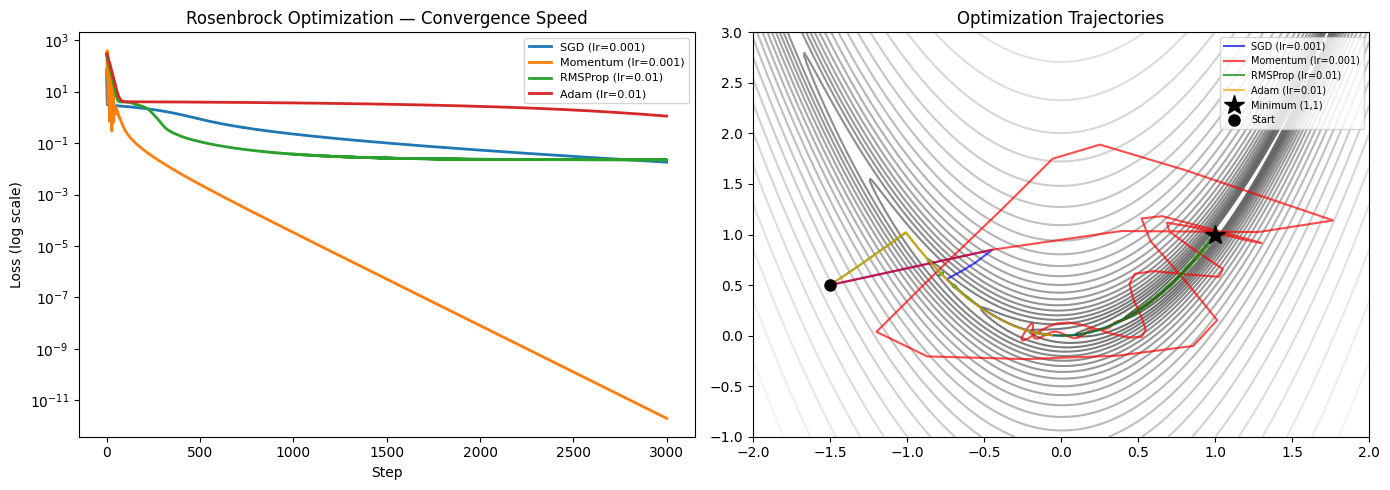

SGD (lr=0.001)           : final loss = 0.018139
Momentum (lr=0.001)      : final loss = 0.000000
RMSProp (lr=0.01)        : final loss = 0.022272
Adam (lr=0.01)           : final loss = 1.120996


In [2]:
# Rosenbrock function: a classical optimization challenge
# f(x,y) = (1-x)^2 + 100(y-x^2)^2
# Minimum at (1, 1)

def rosenbrock(params):
    x, y = params[0][0], params[0][1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(params):
    x, y = params[0][0], params[0][1]
    dfdx = -2*(1-x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return [np.array([dfdx, dfdy])]

n_steps = 3000
start   = [-1.5, 0.5]

optimizers = {
    'SGD (lr=0.001)':       SGD(lr=0.001),
    'Momentum (lr=0.001)':  SGDMomentum(lr=0.001, momentum=0.9),
    'RMSProp (lr=0.01)':    RMSProp(lr=0.01),
    'Adam (lr=0.01)':       Adam(lr=0.01),
}

trajectories = {}
for name, opt in optimizers.items():
    params = [np.array(start, dtype=float)]
    traj   = [params[0].copy()]
    losses = []
    for _ in range(n_steps):
        g = rosenbrock_grad(params)
        params = opt.step(params, g)
        traj.append(params[0].copy())
        losses.append(rosenbrock(params))
    trajectories[name] = (np.array(traj), np.array(losses))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax = axes[0]
for name, (traj, losses) in trajectories.items():
    ax.semilogy(losses, lw=2, label=name)
ax.set_xlabel('Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('Rosenbrock Optimization — Convergence Speed')
ax.legend(fontsize=8)

# Trajectories on contour plot
ax = axes[1]
x_g = np.linspace(-2, 2, 300)
y_g = np.linspace(-1, 3, 300)
X_g, Y_g = np.meshgrid(x_g, y_g)
Z_g = (1 - X_g)**2 + 100*(Y_g - X_g**2)**2
ax.contour(X_g, Y_g, np.log(Z_g + 1), levels=30, cmap='gray', alpha=0.6)
colors = ['blue', 'red', 'green', 'orange']
for (name, (traj, _)), color in zip(trajectories.items(), colors):
    ax.plot(traj[:, 0], traj[:, 1], '-', color=color, lw=1.5, alpha=0.7, label=name)
ax.plot(1, 1, 'k*', ms=15, label='Minimum (1,1)', zorder=10)
ax.plot(start[0], start[1], 'ko', ms=8, label='Start')
ax.set_xlim(-2, 2); ax.set_ylim(-1, 3)
ax.set_title('Optimization Trajectories')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

for name, (_, losses) in trajectories.items():
    print(f"{name:<25}: final loss = {losses[-1]:.6f}")

## 4. Regularization as Constrained Optimization

L2 regularization (weight decay) adds a penalty $\lambda \|\theta\|^2$ to the loss. Equivalently it is optimization subject to $\|\theta\|^2 \leq C$ for some $C(\lambda)$.

Bayesian interpretation: L2 regularization corresponds to a Gaussian prior on weights. L1 regularization corresponds to a Laplace prior.

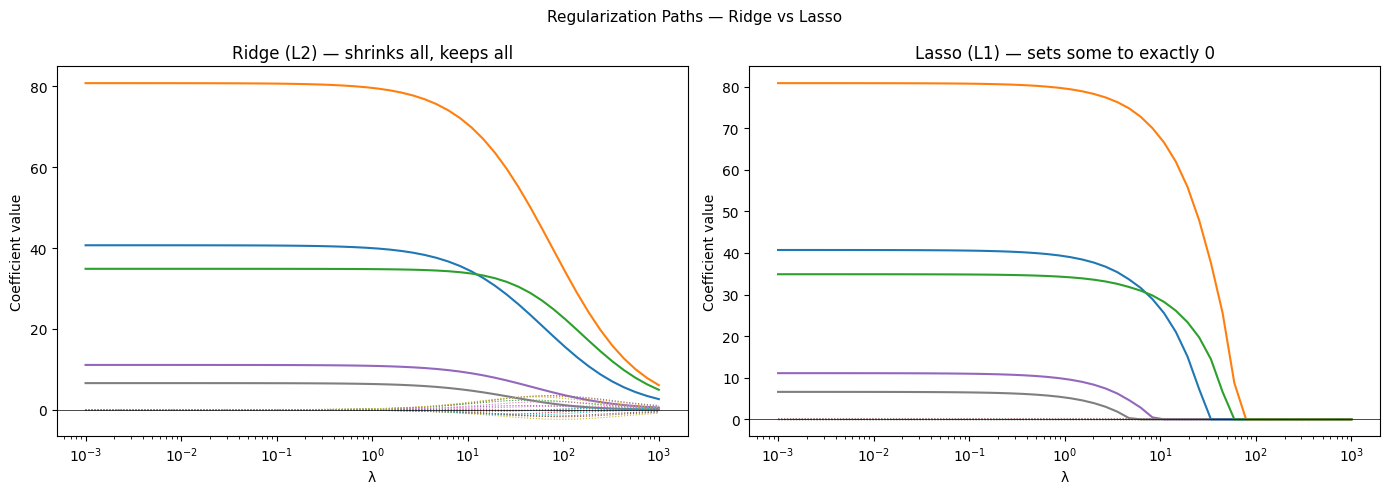

In [3]:
# Demonstrate regularization paths
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import make_regression

X_reg, y_reg, true_coef = make_regression(
    n_samples=100, n_features=20, n_informative=5,
    coef=True, random_state=42
)

lambdas = np.logspace(-3, 3, 50)
ridge_coefs = [Ridge(alpha=l).fit(X_reg, y_reg).coef_ for l in lambdas]
lasso_coefs = [Lasso(alpha=l, max_iter=5000).fit(X_reg, y_reg).coef_ for l in lambdas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, coefs, title in [
    (axes[0], ridge_coefs, 'Ridge (L2) — shrinks all, keeps all'),
    (axes[1], lasso_coefs, 'Lasso (L1) — sets some to exactly 0'),
]:
    coefs = np.array(coefs)
    for j in range(coefs.shape[1]):
        linestyle = '-' if true_coef[j] != 0 else ':'
        ax.semilogx(lambdas, coefs[:, j], ls=linestyle, lw=1.5 if linestyle=='-' else 0.8)
    ax.set_xlabel('λ'); ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.axhline(0, color='black', lw=0.5)

plt.suptitle('Regularization Paths — Ridge vs Lasso', fontsize=11)
plt.tight_layout()
plt.show()

## 5. What Comes Next

All optimization so far assumes data fits in memory. **ch297 — Large Scale Data** addresses the regime where data exceeds RAM: mini-batch processing, streaming algorithms, and distributed computation. The Adam optimizer developed here is the standard optimizer for large-scale neural network training precisely because it handles sparse gradients efficiently — a property that matters critically at scale.